# Factor AI Lab 04 — robust PDV tracking, uncertainty, and abstention (draft)

Notebook 02 asked whether a CNN could replace a peak-ridge estimator. This draft gives machine learning a narrower and more useful job: **correct a strong conventional estimate, estimate uncertainty, and admit ambiguity**.

## Explain it like I am five
The bright line in a spectrogram is like a trail through a snowy forest. Picking the brightest spot in every photograph can jump onto the wrong trail. A continuity tracker remembers where the trail was one moment ago. The residual CNN acts like a helper that suggests small corrections and raises its hand when two trails look believable.

## Draft evaluation contract
- **Decision:** determine when a PDV-derived speed trace is usable and when another measurement or human review is required.
- **Observed:** detector voltage, sample rate, wavelength, and declared calibration metadata.
- **Outputs:** speed magnitude, uncertainty scale, and abstention probability at every STFT frame.
- **Baselines:** independent peak ridge and a continuity-aware dynamic-programming ridge.
- **Candidate:** residual temporal CNN supplied the same spectrogram and baseline trace.
- **Development regimes:** nominal, low SNR, dropout, and two returns.
- **Primary metrics:** per-shot MAE, bias, tail error, interval coverage/width, abstention rate, and retained-versus-abstained error.
- **Failure gates:** no average may hide a failed regime; false confidence on ambiguous frames is a failure.
- **Locked test:** generated from separate seeds and remains closed until `OPEN_LOCKED_TEST=True`.
- **Boundary:** simulator truth is exact only inside this generator. Real PDV validation remains separate.

In [15]:
from dataclasses import dataclass
import copy, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import ShortTimeFFT
import torch
from torch import nn

sns.set_theme(style='whitegrid', context='notebook')
DEVICE=torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
FS=4e9; WAVELENGTH=1550e-9; N=1024; MAX_SPEED=1300.; N_BINS=96
T=np.arange(N)/FS; VGRID=np.linspace(0,MAX_SPEED,N_BINS)
OPEN_LOCKED_TEST=False
print(f'Python {platform.python_version()} | PyTorch {torch.__version__} | {DEVICE}')

Python 3.12.14 | PyTorch 2.14.0 | mps


## 1. Harder forward model
Every shot records the nuisance regime and an evaluator-only ambiguity mask. The two-return case is intentionally not forced into a unique answer where the secondary return is comparable to the primary return.

In [16]:
REGIMES=('nominal','low_snr','dropout','dual_return')

def smoothstep(x):
    x=np.clip(x,0,1); return x*x*(3-2*x)

def simulate(seed,regime):
    rng=np.random.default_rng(seed); u=np.linspace(0,1,N)
    speed=np.clip(rng.uniform(70,180)+rng.uniform(480,780)*smoothstep((u-rng.uniform(.08,.2))/rng.uniform(.5,.78))
                  +rng.uniform(15,65)*np.sin(2*np.pi*(rng.uniform(.7,1.7)*u+rng.random())),20,MAX_SPEED-180)
    amp=1+.2*np.sin(2*np.pi*(rng.uniform(.4,1.3)*u+rng.random()))
    sigma=.10; secondary=np.zeros(N); ambiguous=np.zeros(N,dtype=bool)
    if regime=='low_snr': sigma=.32
    if regime=='dropout':
        center=rng.uniform(.4,.75); width=rng.uniform(.025,.065)
        amp*=1-rng.uniform(.75,.98)*np.exp(-.5*((u-center)/width)**2)
        ambiguous=np.abs(u-center)<1.4*width
    if regime=='dual_return':
        center=rng.uniform(.35,.68); width=rng.uniform(.07,.14); envelope=np.exp(-.5*((u-center)/width)**2)
        other=np.clip(speed+rng.choice([-1,1])*rng.uniform(110,260),0,MAX_SPEED)
        phase2=2*np.pi*np.cumsum(2*other/WAVELENGTH)/FS+rng.uniform(0,2*np.pi)
        ratio=rng.uniform(.55,1.05)*envelope; secondary=ratio*np.cos(phase2)
        ambiguous=ratio>.55
    phase=2*np.pi*np.cumsum(2*speed/WAVELENGTH)/FS+rng.uniform(0,2*np.pi)
    drift=rng.uniform(.04,.16)*np.sin(2*np.pi*rng.uniform(3e6,18e6)*T+rng.random())
    voltage=amp*np.cos(phase)+secondary+drift+rng.normal(0,sigma,N)
    return {'seed':seed,'regime':regime,'voltage':voltage.astype('float32'),
            'speed':speed.astype('float32'),'ambiguous':ambiguous}

train=[simulate(10000+i,REGIMES[i%4]) for i in range(64)]
dev=[simulate(20000+i,REGIMES[i%4]) for i in range(32)]
locked=[simulate(30000+i,REGIMES[i%4]) for i in range(48)]
print('shots:',len(train),'train,',len(dev),'development,',len(locked),'locked test')

shots: 64 train, 32 development, 48 locked test


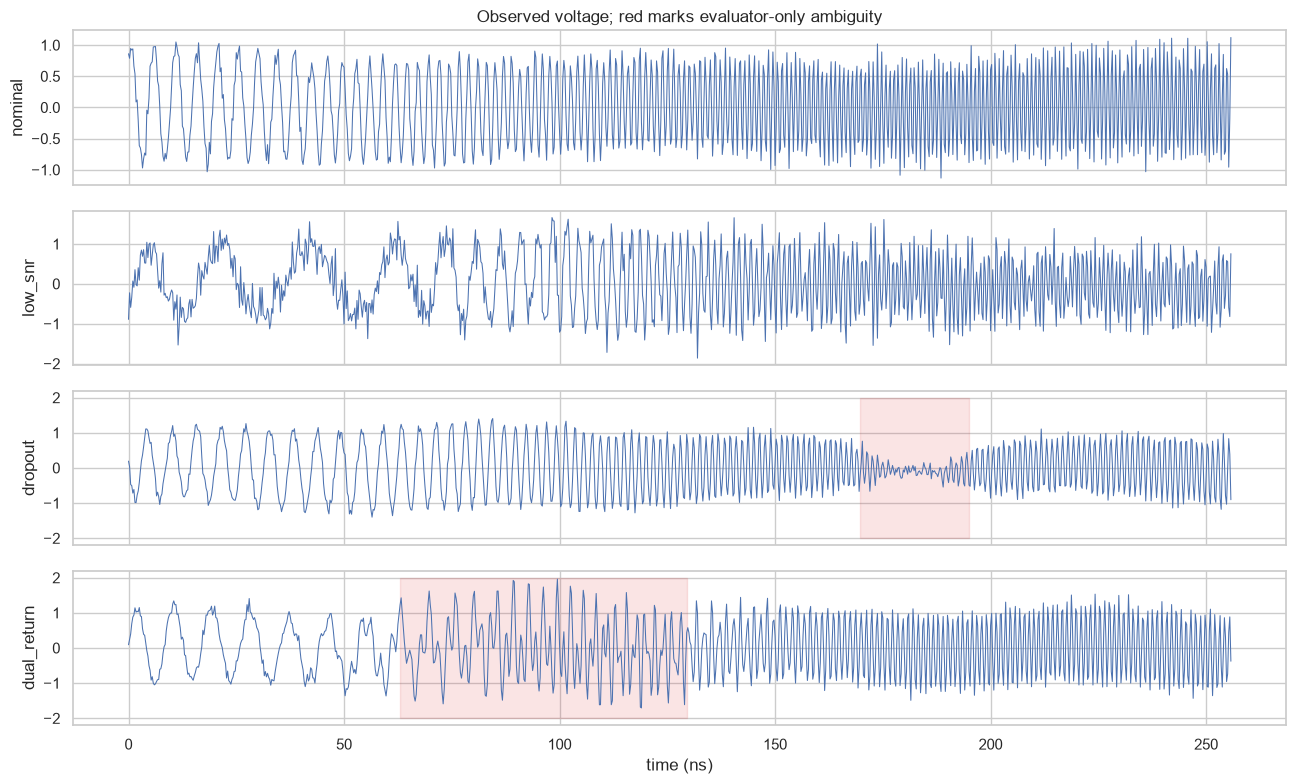

In [17]:
fig,axes=plt.subplots(4,1,figsize=(13,8),sharex=True)
for ax,regime in zip(axes,REGIMES):
    shot=next(s for s in dev if s['regime']==regime)
    ax.plot(T*1e9,shot['voltage'],linewidth=.75); ax.set_ylabel(regime)
    ax.fill_between(T*1e9,-2,2,where=shot['ambiguous'],color='tab:red',alpha=.12)
axes[-1].set_xlabel('time (ns)'); axes[0].set_title('Observed voltage; red marks evaluator-only ambiguity')
plt.tight_layout(); plt.show()

## 2. Two conventional baselines
The independent ridge chooses the brightest bin at each time. The continuity tracker chooses an entire path, trading spectral brightness against implausibly large jumps. The continuity penalty must be selected on development shots only.

In [18]:
STFT=ShortTimeFFT.from_window('hann',fs=FS,nperseg=96,noverlap=72,mfft=768,scale_to='magnitude')

def transform(shot):
    mag=np.abs(STFT.stft(shot['voltage'])); ft=STFT.t(N)
    keep=(ft>=0)&(ft<=T[-1]); mag=mag[:,keep]; ft=ft[keep]
    native=WAVELENGTH*STFT.f/2; usable=native<=MAX_SPEED
    spec=np.stack([np.interp(VGRID,native[usable],mag[usable,j]) for j in range(mag.shape[1])],axis=1)
    spec=np.clip((20*np.log10(spec/(spec.max()+1e-12)+1e-6)+60)/60,0,1).astype('float32')
    truth=np.interp(ft,T,shot['speed']).astype('float32')
    ambiguity=np.interp(ft,T,shot['ambiguous'].astype(float))>.35
    return spec,truth,ambiguity,ft

def peak_ridge(spec): return VGRID[np.argmax(spec,axis=0)]

def continuity_ridge(spec,jump_penalty=.035):
    bins,times=spec.shape; distance=np.abs(np.arange(bins)[:,None]-np.arange(bins)[None,:])
    score=np.empty_like(spec); back=np.zeros((bins,times),dtype=np.int16); score[:,0]=spec[:,0]
    for t in range(1,times):
        choices=score[:,t-1][None,:]-jump_penalty*distance
        back[:,t]=np.argmax(choices,axis=1); score[:,t]=spec[:,t]+choices[np.arange(bins),back[:,t]]
    path=np.empty(times,dtype=int); path[-1]=np.argmax(score[:,-1])
    for t in range(times-1,0,-1): path[t-1]=back[path[t],t]
    return VGRID[path]

def mae(pred,truth,mask=None):
    if mask is None: mask=np.ones_like(truth,dtype=bool)
    return np.mean(np.abs(pred[mask]-truth[mask]))

penalties=[0,.01,.02,.035,.05,.08,.12]
rows=[]
for penalty in penalties:
    errors=[]
    for shot in dev:
        spec,truth,amb,_=transform(shot); errors.append(mae(continuity_ridge(spec,penalty),truth,~amb))
    rows.append({'jump_penalty':penalty,'development_MAE':np.mean(errors)})
baseline_search=pd.DataFrame(rows); BEST_PENALTY=float(baseline_search.loc[baseline_search.development_MAE.idxmin(),'jump_penalty'])
display(baseline_search.round(2)); print('Selected continuity penalty:',BEST_PENALTY)

,jump_penalty,development_MAE
0,0.00,3.71
1,0.01,3.80
2,0.02,4.17
3,0.04,4.56
4,0.05,4.93
5,0.08,5.54
6,0.12,6.28


Selected continuity penalty: 0.0


## 3. Residual CNN with uncertainty and abstention
The CNN receives 96 spectral channels plus the normalized continuity trace and peak prominence. It predicts three quantities per time: a bounded correction, a positive uncertainty scale, and an ambiguity logit. The velocity loss is Gaussian negative log likelihood; ambiguity uses binary cross entropy.

In [19]:
class ResidualPDVCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.body=nn.Sequential(nn.Conv1d(N_BINS+2,64,5,padding=2),nn.GELU(),
                                nn.Conv1d(64,48,5,padding=2),nn.GELU(),
                                nn.Conv1d(48,24,3,padding=1),nn.GELU())
        self.head=nn.Conv1d(24,3,1)
    def forward(self,x,base):
        raw=self.head(self.body(x)); correction=140*torch.tanh(raw[:,0])
        mean=torch.clamp(base+correction,0,MAX_SPEED)
        sigma=3+torch.nn.functional.softplus(raw[:,1])*45
        return mean,sigma,raw[:,2]

def tensors(shots):
    features=[]; bases=[]; truths=[]; ambiguities=[]
    for shot in shots:
        spec,truth,amb,_=transform(shot); base=continuity_ridge(spec,BEST_PENALTY).astype('float32')
        ordered=np.sort(spec,axis=0); prominence=(ordered[-1]-ordered[-2]).astype('float32')
        x=np.concatenate([spec,(base/MAX_SPEED)[None],prominence[None]],axis=0)
        features.append(x); bases.append(base); truths.append(truth); ambiguities.append(amb.astype('float32'))
    return tuple(torch.tensor(np.stack(v),device=DEVICE) for v in (features,bases,truths,ambiguities))

def train_model(seed,epochs=800):
    torch.manual_seed(seed); model=ResidualPDVCNN().to(DEVICE); opt=torch.optim.AdamW(model.parameters(),lr=1e-3)
    x,b,y,a=tensors(train); xd,bd,yd,ad=tensors(dev); best={'mae':np.inf,'state':None}; history=[]
    for epoch in range(1,epochs+1):
        model.train(); opt.zero_grad(); mean,sigma,logit=model(x,b)
        usable=1-a; nll=((.5*((y-mean)/sigma)**2+torch.log(sigma))*usable).sum()/usable.sum()
        ambiguity=nn.functional.binary_cross_entropy_with_logits(logit,a); loss=nll+.35*ambiguity
        loss.backward(); opt.step(); model.eval()
        with torch.no_grad():
            md,sd,ld=model(xd,bd); dev_mae=((md-yd).abs()*(1-ad)).sum()/(1-ad).sum()
        if dev_mae.item()<best['mae']: best={'mae':dev_mae.item(),'state':copy.deepcopy(model.state_dict())}
        if epoch==1 or epoch%20==0: history.append({'epoch':epoch,'dev_MAE':dev_mae.item(),'loss':loss.item()})
    model.load_state_dict(best['state']); return model,pd.DataFrame(history),best['mae']

runs=[]; started=time.perf_counter()
for seed in (41, 42, 43, 44, 45, 46, 47, 48):
    model,history,score=train_model(seed); runs.append({'seed':seed,'model':model,'history':history,'dev_mae':score})
    print('seed',seed,'development MAE',round(score,2),'m/s')
best=min(runs,key=lambda r:r['dev_mae']); print('training seconds:',round(time.perf_counter()-started,1))

seed 41 development MAE 3.71 m/s
seed 42 development MAE 3.7 m/s
seed 43 development MAE 3.69 m/s
seed 44 development MAE 3.69 m/s
seed 45 development MAE 3.7 m/s
seed 46 development MAE 3.72 m/s
seed 47 development MAE 3.72 m/s
seed 48 development MAE 3.69 m/s
training seconds: 17.7


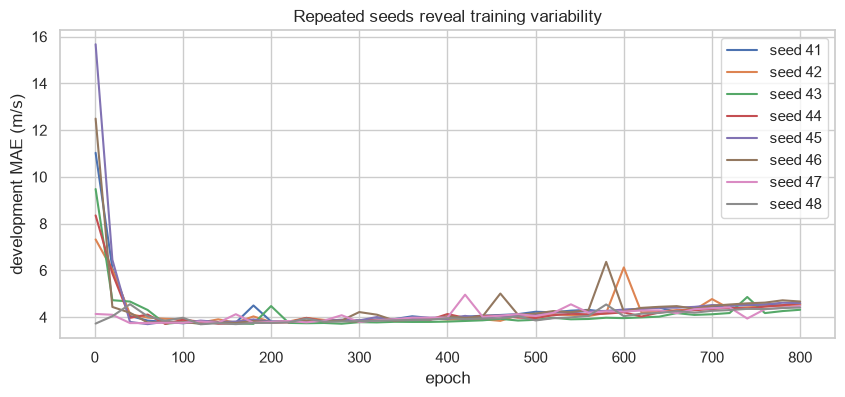

In [20]:
fig,ax=plt.subplots(figsize=(10,4))
for run in runs: ax.plot(run['history'].epoch,run['history'].dev_MAE,label=f"seed {run['seed']}")
ax.set(xlabel='epoch',ylabel='development MAE (m/s)',title='Repeated seeds reveal training variability'); ax.legend(); plt.show()

## 4. Locked evaluation
The cell below refuses to inspect the locked set unless you deliberately change the switch at the top. Before opening it, freeze the model, uncertainty calibration method, abstention threshold, metrics, and acceptance gates. Once opened, create new seeds for any later model change.

In [21]:
if not OPEN_LOCKED_TEST:
    print('LOCKED TEST REMAINS CLOSED. Develop using train and dev only.')
else:
    rows=[]; model=best['model']; model.eval()
    for shot in locked:
        spec,truth,amb,_=transform(shot); peak=peak_ridge(spec); cont=continuity_ridge(spec,BEST_PENALTY)
        ordered=np.sort(spec,axis=0); prominence=(ordered[-1]-ordered[-2]).astype('float32')
        xin=np.concatenate([spec,(cont/MAX_SPEED)[None],prominence[None]],axis=0)
        with torch.no_grad():
            mean,sigma,logit=model(torch.tensor(xin[None],device=DEVICE),torch.tensor(cont[None],device=DEVICE,dtype=torch.float32))
        mean=mean.cpu().numpy()[0]; sigma=sigma.cpu().numpy()[0]; prob=torch.sigmoid(logit).cpu().numpy()[0]
        for name,pred in [('peak',peak),('continuity',cont),('residual CNN',mean)]:
            rows.append({'shot':shot['seed'],'regime':shot['regime'],'method':name,'MAE':mae(pred,truth,~amb)})
        rows[-1].update({'coverage_95':np.mean(np.abs(mean[~amb]-truth[~amb])<=1.96*sigma[~amb]),
                         'false_confidence':np.mean((prob[amb]<.5)) if amb.any() else np.nan})
    locked_results=pd.DataFrame(rows)
    display(locked_results.groupby(['regime','method']).mean(numeric_only=True).round(2))

LOCKED TEST REMAINS CLOSED. Develop using train and dev only.


## 5. Bridge to a real waveform
Replace one synthetic `voltage` array only after recording: sample interval, laser wavelength, trigger reference, voltage units, detector/digitizer bandwidth, filtering already applied, saturation codes, missing samples, and the analyst reconstruction with its uncertainty. First inspect whether real nuisance behavior resembles any generator regime. Do not score against an analyst trace as if it were exact truth.

## Draft checklist
- [ ] Verify the Viterbi implementation against a hand-constructed ridge.
- [ ] Calibrate uncertainty on development shots rather than trusting raw neural sigma.
- [ ] Freeze regime-specific acceptance gates before opening the test.
- [ ] Add a generator implemented independently from the inverse pipeline.
- [ ] Add timing, wavelength, bandwidth, saturation, and clock uncertainty.
- [ ] Decide whether dual-return frames have a defined primary target or require abstention.
- [ ] Evaluate multiple seeds and report shot-level confidence intervals.
- [ ] Inspect one real waveform without calling its analyst reconstruction perfect truth.